# Lesson 2: Diffusion samplers


## Hyperparameters

All experiment settings are collected below. The 1D forward demo also has live controls. After editing this panel, rerun from the top; after editing a kernel, rerun its visualization cell.

In [14]:
# HYPERPARAMETERS — edit here, then Run All

# Interactive 1D forward demo (initial slider values)
DEMO_PRIOR_STD = 1.0          # Standard deviation nu of the centered Gaussian prior.
DEMO_DIFFUSION_STEPS = 600    # Number K of forward transitions.
DEMO_SCHEDULE = "linear"      # Linear noising preset; also try "constant" or "cosine".
DEMO_DELTA_START = 0.005      # Gentle initial noising; first coefficient delta_0.
DEMO_DELTA_END = 0.035        # Final coefficient delta_K; enough total noise to merge the peaks.
DEMO_MODE_LOCATION = 3.0     # Centers of the two equally weighted modes: +/- this value.
DEMO_COMPONENT_STD = 0.55    # Standard deviation of each initial Gaussian peak.
DEMO_PARTICLES = 4096        # Samples for smoother animated histograms.
DEMO_SEED = 17               # Repeatable particle and transition noise.
DEMO_FRAMES = 81             # Maximum number of displayed diffusion snapshots.
DEMO_INTERVAL_MS = 120       # Playback interval between snapshots, in milliseconds.
TORCH_NUM_THREADS = 2        # CPU threads; these small models do not need many.

# Reverse demo: the checkpoint fixes its prior, K, schedule, target, and model.
DEMO_CHECKPOINT = "assets/bimodal_score.pt"  # Local pretrained weights, relative to this lesson.
# Its paired JSON fixes nu=1, K=600, and linear delta=0.005 -> 0.035.
# DEMO_PARTICLES, DEMO_SEED, and playback settings also apply to reverse viewing.

# Later: GMM-40 diffusion-sampler training (independent of the 1D controls)

# Objective and target distribution
TEMPERATURE = 1.0             # Fixed target temperature T throughout training (positive).
NUM_MODES = 40                # Number of equally weighted Gaussian target modes.
MODE_BOUND = 40.0             # Mode centers lie in [-MODE_BOUND, MODE_BOUND]^2.
TARGET_VARIANCE = 1.0         # Variance of each target component per coordinate.
TARGET_SEED = 0               # Seed that fixes the target's component locations.

# Diffusion family and score network
NUM_DIFFUSION_STEPS = 24      # K transitions, with K+1 noise coefficients.
PRIOR_STD = 30.0              # Fixed Gaussian prior scale nu; not learned by the code.
BETA_START = 5e-4             # Fixed first coefficient beta_0.
BETA_END = 2e-3               # Fixed last coefficient beta_K.
DIFFUSION_STEP_SIZE = 1.0     # Delta; each noise coefficient is delta_k = beta_k * Delta.
LEARN_DIFFUSION_SCHEDULE = False  # Optimize the monotone interior beta coefficients.
SCORE_WIDTH = 96             # Score-network hidden width; gradient gate uses half.
# The comparison always runs both estimators, with Langevin off and on.

# Optimization (shared by all four runs)
SEED = 11                    # Shared seed for network initialization and training.
TRAINING_STEPS = 800         # Number of optimizer updates per configuration.
BATCH_SIZE = 256             # Sampled diffusion paths per update (at least 2).
LEARNING_RATE = 5e-4          # Adam learning rate for the score network.
SCHEDULE_LEARNING_RATE = 3e-4 # Adam learning rate for learned schedule parameters.
MAX_GRAD_NORM = 10.0         # Upper bound on the norm of an optimizer gradient.

# Evaluation and animation
LOG_EVERY = 40               # Record diagnostics every this many updates.
NUM_EVAL_SAMPLES = 5000      # Fresh samples for the final mode-recovery diagnostic.
EVALUATION_SEED = 31         # Seed for the mode-recovery samples.
MODE_CAPTURE_RADIUS = 1.25   # Maximum distance to a center to count captured mass.
MINIMUM_MODE_FRACTION = 0.005 # Minimum captured mass to mark a mode as recovered.
NUM_GIF_SAMPLES = 600        # Fixed-noise particles per panel and path-loss estimate.
ANIMATION_SEED = 10011       # Shared seed for the fixed prior and transition noise.
GIF_FPS = 1.5                # Saved animation frames per second.
GIF_DPI = 92                 # Saved animation resolution in dots per inch.
PLOT_BOUND = 56.0            # Plot both coordinates over [-PLOT_BOUND, PLOT_BOUND].
GRID_RESOLUTION = 360        # Grid points per coordinate for the target contours.
CONTOUR_LEVELS = 80          # Number of target-reward contour levels.
REWARD_PLOT_RANGE = 100.0    # Display rewards within this distance below the maximum.

# Numerical stability (implementation settings)
LANGEVIN_GRADIENT_CLIP = 1e2 # Bound on each analytic target-gradient coordinate.
LANGEVIN_DRIFT_CLIP = 1e4    # Bound on each preconditioned drift coordinate.


## First understand diffusion, then train a sampler

- **Task 1:** implement the forward kernel; watch a two-peak Gaussian mixture become approximately Gaussian.
- **Task 2:** implement the reverse kernel; use a pretrained score to recover the two peaks.
- **Tasks 3–4:** implement the kernel log probabilities; reuse the same kernels to train the 2D GMM-40 sampler.

We use the discrete equations from the slides, with $\delta_j=\beta_j\Delta_j$ and $\Delta_j=1$ in the 1D demo. There are $K$ transitions and $K+1$ coefficients. For a pair $(x^{k-1},x^k)$, the forward kernel uses $\delta_{k-1}$ and the reverse kernel uses $\delta_k$. The caller passes the appropriate `delta`, `prior_std`, and mathematical `step_index` $k\in\{1,\ldots,K\}$.


## Setup

Run this cell once before implementing the kernels. The interactive demos use the controls above; the later GMM-40 experiment has its own settings in the same panel.

In [15]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch.distributions import Independent, Normal
from IPython.display import display

torch.set_num_threads(TORCH_NUM_THREADS)

lesson_directory = Path("L2-DiffusionSamplers")
if not lesson_directory.is_dir():
    lesson_directory = Path(".")
sys.path.insert(0, str(lesson_directory.resolve()))

torch.manual_seed(SEED)

## Task 1: implement the discrete forward step

The forward step shrinks the previous state and adds independent Gaussian noise:

$$x^k=(1-\tfrac12\delta_{k-1})x^{k-1}+\nu\sqrt{\delta_{k-1}}\,\varepsilon_{k-1},\qquad\varepsilon_{k-1}\sim\mathcal N(0,I).$$

Thus $p(x^k\mid x^{k-1})=\mathcal N((1-\tfrac12\delta_{k-1})x^{k-1},\nu^2\delta_{k-1}I)$, with $\nu=\texttt{prior\_std}$ supplied by the caller.

**Task:** implement this Gaussian transition for any state dimension (`D=1` in the interactive demo, `D=2` later). Use the supplied `prior_std`, so the prior slider changes your kernel. Support the supplied fixed noise and the `reparameterize` flag, returning a state with the same shape as `previous_state`.

**Optional hints** — click a label to expand.

<details>
<summary><strong>Get a hint: Gaussian parameters</strong></summary>
<p>The mean is <code>(1 - 0.5 * delta) * previous_state</code> and the standard deviation is <code>prior_std * torch.sqrt(delta)</code>. Multiply standard-normal noise by this standard deviation, not by the variance.</p>
</details>

<details>
<summary><strong>Get a hint: choosing epsilon</strong></summary>
<p>Use the supplied <code>noise</code> as <code>epsilon</code>. If it is <code>None</code>, draw <code>epsilon = torch.randn_like(previous_state)</code>. The animation supplies fixed standard-normal noise to follow the same particles across iterations. After choosing epsilon, use the same sampling formula in both cases.</p>
</details>

<details>
<summary><strong>Get a hint: sampling and shapes</strong></summary>
<p>Construct <code>sample = mean + sigma * epsilon</code> explicitly, with <code>sigma</code> the standard deviation, as in Lesson 1. Return this sample for <code>reparameterize=True</code>; otherwise use <code>sample.detach()</code> to stop the gradient. The input and output both have shape <code>(batch_size, D)</code>.</p>
</details>

In [16]:
def forward_sde_step(
    previous_state: torch.Tensor,
    delta: torch.Tensor,
    *,
    reparameterize: bool,
    noise: torch.Tensor | None = None,
    prior_std: float = PRIOR_STD,
) -> torch.Tensor:
    """One variance-preserving forward noising step."""
    mean = (1.0 - 0.5 * delta) * previous_state
    standard_deviation = prior_std * delta.sqrt()
    if noise is None:
        noise = torch.randn_like(previous_state)
    sample = mean + standard_deviation * noise
    return sample if reparameterize else sample.detach()

### Try your forward kernel

- Start from $\tfrac12\mathcal N(-3,0.55^2)+\tfrac12\mathcal N(3,0.55^2)$.
- **Ready-to-run preset:** $\nu=1$, $K=600$, linear $\delta_k=0.005+0.03\,k/K$, and 4096 particles.
- **Sliders:** prior standard deviation $\nu$, number of steps $K$, and noise coefficients. Choose a constant, linear, or cosine ramp of $\delta_k$.
- **Play / scrub:** blue histograms and moving particles come from your `forward_sde_step`; the orange curve is the expected marginal.
- Try fewer steps or weaker noise: does a second peak remain? With sufficient noising and small steps, the endpoint approaches $\mathcal N(0,\nu^2)$ approximately.

Only Task 1 is needed here. Rerun this cell after editing your kernel. Changing these controls does not change the later reverse demo or GMM-40 training settings.


In [17]:
from lesson2_kernel_demo import DemoConfig, forward_demo

forward_explorer = forward_demo(
    forward_sde_step,
    config=DemoConfig(
        prior_std=DEMO_PRIOR_STD, num_steps=DEMO_DIFFUSION_STEPS,
        schedule=DEMO_SCHEDULE, delta_start=DEMO_DELTA_START, delta_end=DEMO_DELTA_END,
        mode_location=DEMO_MODE_LOCATION, component_std=DEMO_COMPONENT_STD,
    ),
    num_samples=DEMO_PARTICLES, seed=DEMO_SEED,
    frame_count=DEMO_FRAMES, interval_ms=DEMO_INTERVAL_MS,
)
display(forward_explorer)

## Task 2: implement the learned reverse step

The optimal score $s_k^*(x)=\nabla_x\log p_k(x)$ is intractable in general. The score network $u_\Psi(x,k)$ approximates it and gives the reverse mean

$$\mu_\theta(x^k,k)=(1+\tfrac12\delta_k)x^k+\nu^2\delta_k u_\Psi(x^k,k).$$

Sample $x^{k-1}=\mu_\theta(x^k,k)+\nu\sqrt{\delta_k}\,\varepsilon_k$, with $\varepsilon_k\sim\mathcal N(0,I)$. Equivalently,

$$q_\theta(x^{k-1}\mid x^k)=\mathcal N(\mu_\theta(x^k,k),\nu^2\delta_k I).$$

For the visualization below, we provide a pretrained score network for the same two-peak target. Its prior, step count, and schedule are loaded together with its weights. Small Euler steps and a learned score give an approximate reverse process.

**Task:** implement this reverse transition using the supplied score network. Support fixed noise and the `reparameterize` flag, returning a state with the same shape as `noisy_state`.

**Optional hints** — click a label to expand.

<details>
<summary><strong>Get a hint: calling the score network</strong></summary>
<p>Call <code>score_network(noisy_state, step_index, num_steps)</code>. Pass the supplied step arguments directly: <code>step_index</code> is k from 1 through K; the network handles time encoding. The returned score has the same shape as <code>noisy_state</code>, usually <code>(batch_size, D)</code>.</p>
</details>

<details>
<summary><strong>Get a hint: the reverse Gaussian</strong></summary>
<p>Use <code>(1 + 0.5 * delta) * noisy_state + delta * prior_std**2 * score</code> for the mean and <code>sigma = prior_std * torch.sqrt(delta)</code> for the standard deviation. The variance factor <code>prior_std**2</code> in the mean is required by the scaled process in this lesson.</p>
</details>

<details>
<summary><strong>Get a hint: fixed noise and sampling</strong></summary>
<p>Use the supplied <code>noise</code> as <code>epsilon</code>, or draw <code>epsilon = torch.randn_like(noisy_state)</code> when it is <code>None</code>. Construct <code>sample = mean + sigma * epsilon</code> explicitly. Return it for <code>reparameterize=True</code>; otherwise use <code>sample.detach()</code> to stop the gradient. Keep the score and Gaussian parameters attached so reparameterized samples carry gradients into the network.</p>
</details>

In [18]:
def reverse_sde_step(
    score_network,
    noisy_state: torch.Tensor,
    step_index: int,
    delta: torch.Tensor,
    num_steps: int,
    *,
    reparameterize: bool,
    noise: torch.Tensor | None = None,
    prior_std: float = PRIOR_STD,
) -> torch.Tensor:
    """One learned reverse denoising step."""
    score = score_network(noisy_state, step_index, num_steps)
    mean = (1.0 + 0.5 * delta) * noisy_state + delta * prior_std**2 * score
    standard_deviation = prior_std * delta.sqrt()
    if noise is None:
        noise = torch.randn_like(noisy_state)
    sample = mean + standard_deviation * noise
    return sample if reparameterize else sample.detach()

### Try your reverse kernel with a pretrained score

- Load the bundled neural score model: **no training needed**.
- Start from $\mathcal N(0,1)$ and run your `reverse_sde_step` from $k=600$ to $0$.
- **Fixed checkpoint settings:** $\nu=1$, $K=600$, linear $\delta_k=0.005+0.03\,k/K$, and the same two-peak target; 4096 particles by default. Forward-slider changes are ignored here.
- **Play / scrub:** your samples should split into two peaks and approach the target. Compare the blue histogram with the orange reference throughout the process.

The checkpoint was fitted to the scores of the known forward marginals. At inference the neural network supplies the score; the reference curve is only a visual check. Small differences remain because the score and reverse Euler steps are approximate. Only Task 2 is needed here; log-probability functions are not used.


In [19]:
from lesson2_kernel_demo import load_pretrained_demo, reverse_demo

pretrained_demo = load_pretrained_demo(lesson_directory / DEMO_CHECKPOINT)
reverse_explorer = reverse_demo(
    reverse_sde_step, pretrained_demo,
    num_samples=DEMO_PARTICLES, seed=DEMO_SEED,
    frame_count=DEMO_FRAMES, interval_ms=DEMO_INTERVAL_MS,
)
display(reverse_explorer)

## From the 1D demo to diffusion samplers

Now reuse your kernels in two dimensions. The target is the seed-0 GMM-40 distribution and the prior is $\mathcal N(0,\nu^2 I_2)$, using `PRIOR_STD` from the GMM-40 panel (default 30). The training code passes this scale explicitly to every kernel.

Use the hyperparameter panel above for every experiment setting. Rerun from the top after changing it.

`LEARN_DIFFUSION_SCHEDULE=True` learns the monotone interior coefficients while keeping both endpoints fixed. The Gaussian prior scale `PRIOR_STD` is configurable but is **not learned**; learning prior parameters would require extending the code.

The four runs compare reparameterization and log derivative, each with and without Langevin preconditioning. The latter parameterizes the score as

$$u_\Psi(x,k)=-x/\nu^2+\mathrm{NN}_1(k,x)+\mathrm{NN}_2(k)\odot\nabla_x\log p_T(x).$$

The schedule stores $\beta_0,\ldots,\beta_K$. Its $K-1$ interior coefficients can be trained; forward and reverse transitions on the same pair use adjacent coefficients.


In [20]:
from lesson2_common import configure_target

configure_target(
    num_modes=NUM_MODES, mode_bound=MODE_BOUND,
    target_variance=TARGET_VARIANCE, seed=TARGET_SEED,
    plot_bound=PLOT_BOUND, grid_resolution=GRID_RESOLUTION,
    contour_levels=CONTOUR_LEVELS, reward_plot_range=REWARD_PLOT_RANGE,
)

from lesson2_common import (
    DISPLAY_REWARD,
    DiffusionKernels,
    DiffusionSampler,
    GRID_X,
    GRID_Y,
    REWARD_LEVELS,
    check_kernel_functions,
    evaluate_mode_recovery,
    plot_reward_landscape,
    plot_training_summary,
    save_training_comparison_animation,
    train_sampler,
)

torch.manual_seed(SEED)
EXPERIMENTS = [
    (estimator, use_langevin)
    for estimator in ("reparameterization", "log_derivative")
    for use_langevin in (False, True)
]
print(f"Later GMM-40 VP transitions: {NUM_DIFFUSION_STEPS}; coefficients: {NUM_DIFFUSION_STEPS + 1}")
print(f"delta = beta * Delta, Delta={DIFFUSION_STEP_SIZE:g}; beta: {BETA_START:.4f} -> {BETA_END:.4f}")
print(f"Prior standard deviation: {PRIOR_STD:g}; experiments: {EXPERIMENTS}")

Later GMM-40 VP transitions: 24; coefficients: 25
delta = beta * Delta, Delta=1; beta: 0.0005 -> 0.0020
Prior standard deviation: 30; experiments: [('reparameterization', False), ('reparameterization', True), ('log_derivative', False), ('log_derivative', True)]


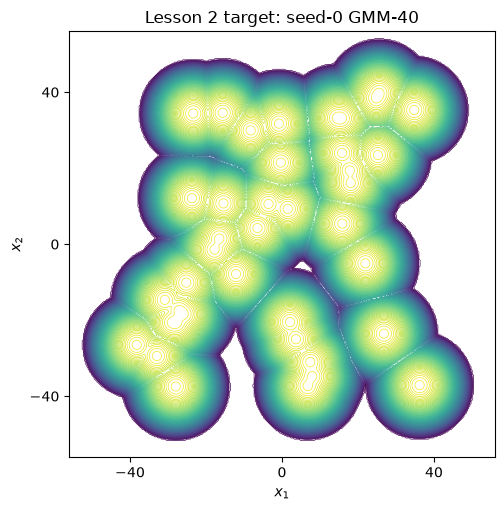

In [21]:
fig, axis = plt.subplots(figsize=(6.4, 5.2))
plot_reward_landscape(axis)
axis.set_title(f"Lesson 2 target: seed-{TARGET_SEED} GMM-{NUM_MODES}")
plt.tight_layout()
plt.show()

## 3. Forward and reverse kernel log probabilities

Evaluate each realized transition under the same Gaussian used to sample it. The forward covariance is $\nu^2\delta_{k-1}I$; the reverse covariance is $\nu^2\delta_k I$. The caller supplies the correct coefficient as `delta`. `Independent(Normal(mean, std), 1)` returns one log probability per 2D sample.

In [22]:
def forward_kernel_log_prob(
    previous_state: torch.Tensor,
    noisy_state: torch.Tensor,
    delta: torch.Tensor,
    *,
    prior_std: float = PRIOR_STD,
) -> torch.Tensor:
    """Evaluate log p(x^k | x^{k-1})."""
    mean = (1.0 - 0.5 * delta) * previous_state
    distribution = Independent(Normal(mean, prior_std * delta.sqrt()), 1)
    return distribution.log_prob(noisy_state)


def reverse_kernel_log_prob(
    score_network,
    previous_state: torch.Tensor,
    noisy_state: torch.Tensor,
    step_index: int,
    delta: torch.Tensor,
    num_steps: int,
    *,
    prior_std: float = PRIOR_STD,
) -> torch.Tensor:
    """Evaluate log q_theta(x^{k-1} | x^k)."""
    score = score_network(noisy_state, step_index, num_steps)
    mean = (1.0 + 0.5 * delta) * noisy_state + delta * prior_std**2 * score
    distribution = Independent(Normal(mean, prior_std * delta.sqrt()), 1)
    return distribution.log_prob(previous_state)

## 4. Check the four implementations

The checks cover shapes, finite values, and gradients through the score network and the schedule.

In [23]:
kernels = DiffusionKernels(
    forward_sde_step=forward_sde_step,
    reverse_sde_step=reverse_sde_step,
    forward_kernel_log_prob=forward_kernel_log_prob,
    reverse_kernel_log_prob=reverse_kernel_log_prob,
)
check_kernel_functions(kernels, prior_std=PRIOR_STD, num_steps=NUM_DIFFUSION_STEPS)

All four VP-kernel checks passed.


## The path-space upper bound and gradient estimators

For $p_T(x^0)\propto\exp(R(x^0)/T)$, data processing gives

$$\mathrm{KL}(q_\theta(x^0)\|p_T(x^0))\leq\mathrm{KL}(q_\theta(x^{0:K})\|p_T(x^{0:K})).$$

After multiplying by $T$ and dropping the constant $T\log Z_T$, the optimized path cost is

$$\mathbb E_{q_\theta}\!\left[-R(x^0)+T\left(\log q_K(x^K)+\sum_k\log q_\theta(x^{k-1}\mid x^k)-\sum_k\log p(x^k\mid x^{k-1})\right)\right].$$

Both the reparameterization estimator and the leave-one-out log-derivative estimator are implemented in <code>lesson2_common.py</code>. They are not student TODOs in this lesson.

## 5. Train the four reverse samplers

The four runs share their random seed, fixed animation noise, schedule, batch size, and training duration. Only the gradient estimator and Langevin preconditioning flag change.

`TEMPERATURE` stays fixed throughout training; there is no temperature annealing. The default 800 updates keep the exercise short. The slides show the separately saved 26,000-update runs, with the same target temperature.


In [24]:
comparison = []
trained_samplers = {}
for gradient_estimator, use_langevin in EXPERIMENTS:
    sampler, history = train_sampler(
        kernels,
        gradient_estimator=gradient_estimator,
        learn_schedule=LEARN_DIFFUSION_SCHEDULE,
        use_langevin_preconditioning=use_langevin,
        seed=SEED,
        steps=TRAINING_STEPS,
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        schedule_learning_rate=SCHEDULE_LEARNING_RATE,
        max_grad_norm=MAX_GRAD_NORM,
        temperature=TEMPERATURE,
        num_steps=NUM_DIFFUSION_STEPS,
        prior_std=PRIOR_STD,
        beta_start=BETA_START,
        beta_end=BETA_END,
        diffusion_step_size=DIFFUSION_STEP_SIZE,
        score_width=SCORE_WIDTH,
        langevin_gradient_clip=LANGEVIN_GRADIENT_CLIP,
        langevin_drift_clip=LANGEVIN_DRIFT_CLIP,
        animation_seed=ANIMATION_SEED,
        log_every=LOG_EVERY,
        num_animation_samples=NUM_GIF_SAMPLES,
    )
    comparison.append((gradient_estimator, use_langevin, history))
    trained_samplers[(gradient_estimator, use_langevin)] = sampler
    _, recovered_modes = evaluate_mode_recovery(
        sampler, num_samples=NUM_EVAL_SAMPLES, seed=EVALUATION_SEED,
        capture_radius=MODE_CAPTURE_RADIUS, minimum_fraction=MINIMUM_MODE_FRACTION,
    )
    label = f"{gradient_estimator:18s} | Langevin={str(use_langevin):5s}"
    print(
        f"{label} | reward {history['mean_reward'][0]:7.2f} -> "
        f"{history['mean_reward'][-1]:7.2f} | recovered {recovered_modes.sum().item():2d}/{NUM_MODES}"
    )

reparameterization | Langevin=False | reward -160.36 ->  -15.04 | recovered  6/40
reparameterization | Langevin=True  | reward -160.36 ->   -7.32 | recovered 29/40
log_derivative     | Langevin=False | reward -160.36 ->  -20.55 | recovered  1/40
log_derivative     | Langevin=True  | reward -160.36 ->   -8.42 | recovered 20/40


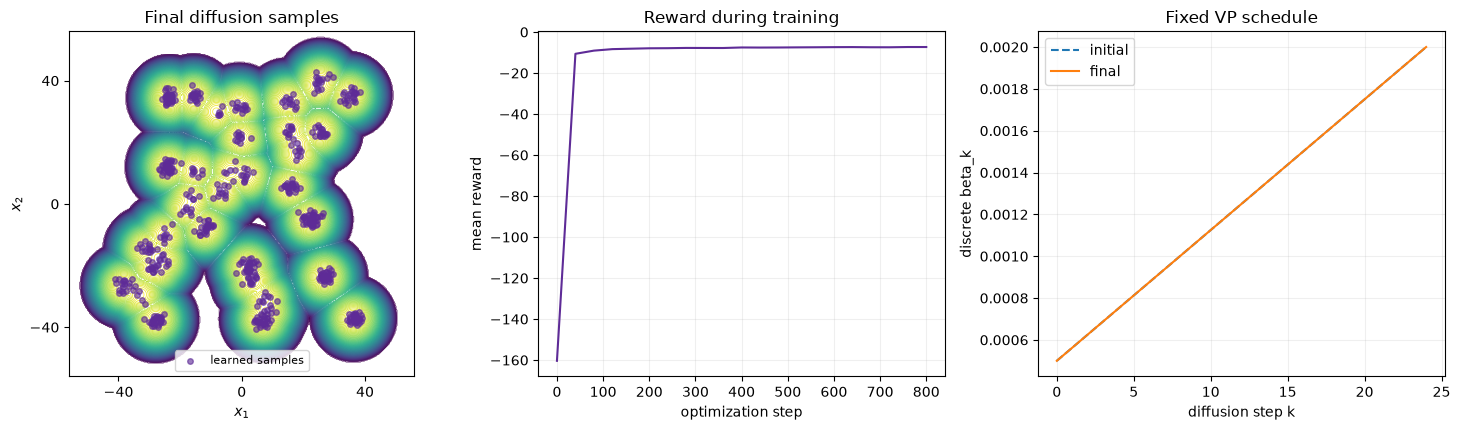

In [25]:
reference_sampler = trained_samplers[("reparameterization", True)]
reference_history = next(
    history for estimator, langevin, history in comparison
    if estimator == "reparameterization" and langevin
)
plot_training_summary(reference_sampler, reference_history)
plt.show()

## 6. Animate samples over training

Every panel reuses the same prior and transition noise. A dot therefore follows the learned transformation, and differences across panels come from the estimator/preconditioner setting. The two loss panels use the same fixed-noise path objective for a fair comparison; their dashed vertical lines and point markers track the current frame.

Columns compare reparameterization (left) and log derivative (middle); rows show Langevin off (top) and on (bottom). The right column compares both estimators' losses on a logarithmic scale.


Saved animation to /home/sebastian/code/SummerSchool/L2-DiffusionSamplers/diffusion_sampler_training.gif


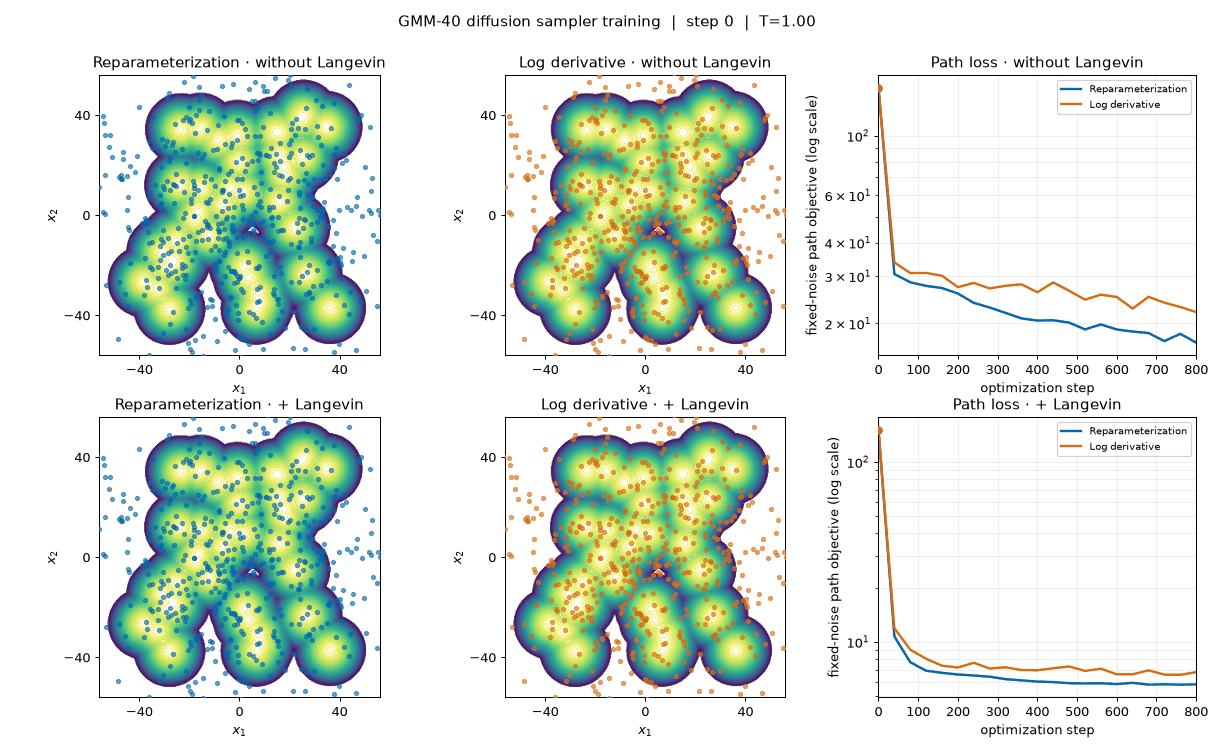

In [26]:
output_directory = Path("L2-DiffusionSamplers")
if not output_directory.is_dir():
    output_directory = Path(".")
gif_path = output_directory / "diffusion_sampler_training.gif"
save_training_comparison_animation(comparison, gif_path, fps=GIF_FPS, dpi=GIF_DPI)
print(f"Saved animation to {gif_path.resolve()}")

from IPython.display import Image, display
display(Image(filename=str(gif_path)))

## Instructor notes

- The broad $\mathcal N(0,30^2I)$ prior matches the GMM-40 coordinate scale.
- The learned schedule changes only monotone interior points; its endpoints remain $5\times10^{-4}$ and $2\times10^{-3}$.
- The pathwise estimator is the recommended default. The whole-path score estimator is intentionally included to connect back to Lesson 1, but it has higher variance.
- A diffusion sampler can divide the prior into regions that flow toward different modes, so its terminal marginal need not be Gaussian or unimodal.
- The upper bound is tractable because every forward and reverse transition density is evaluated along the sampled path.
- The K transitions use K+1 schedule coefficients: forward k-1 and reverse k. For constant delta, the Euler prior variance approaches $\nu^2/(1-\delta/4)$, so finite-step preservation is approximate.